In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Decision Tree Classsifier-
Here are the fundamental mathematical formulas used by Decision Tree Classifiers to evaluate the quality of a split.

In the formulas below, $S$ represents the dataset (or the current node), $c$ represents the total number of classes, and $p_i$ represents the probability (or fraction) of items belonging to class $i$ within that node.

## 1. Entropy

Entropy is a measure of the randomness, uncertainty, or impurity within a node. A node with only one class has an entropy of $0$ (perfectly pure), while a node with an equal number of all classes has maximum entropy.

$$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$

## 2. Gini Impurity

Gini Impurity measures the probability that a randomly chosen element from the node would be incorrectly labeled if it was randomly labeled according to the distribution of classes in the node. Like entropy, a pure node has a Gini score of $0$. It is slightly faster to compute than entropy because it avoids logarithmic functions.

$$G(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

## 3. Information Gain

Information Gain measures the reduction in impurity (either Entropy or Gini) achieved by splitting the data on a specific attribute. The decision tree algorithm calculates the Information Gain for every possible split and chooses the one that yields the highest value (i.e., the largest drop in impurity).

Let $A$ be the attribute you are splitting on, and $S_v$ be the subset of $S$ for which attribute $A$ has the value $v$.

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

* $H(S)$ is the impurity of the parent node (can be calculated using Entropy or Gini).
* $\frac{|S_v|}{|S|}$ is the weight of the child node (number of samples in the child node divided by total samples in the parent node).
* $H(S_v)$ is the impurity of the child node.

Essentially, Information Gain is the **Impurity of the Parent Node** minus the **Weighted Average Impurity of the Child Nodes**.

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris=load_iris()

In [4]:
iris


{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
iris['DESCR']

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [6]:
#multiclass classification-(setosa,versicolor,viriginica)
print(iris['target'])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [7]:
#independent features-
X=pd.DataFrame(iris['data'],columns=['sepal_length','sepal_width','petal_length','petal_width'])

In [8]:
#dependent feature-
y= iris['target']

In [9]:
#TRAIN Test split-
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
## apply DT classifier-
from sklearn.tree import DecisionTreeClassifier
treeclassifier = DecisionTreeClassifier()
treeclassifier.fit(X_train,y_train)

DecisionTreeClassifier()

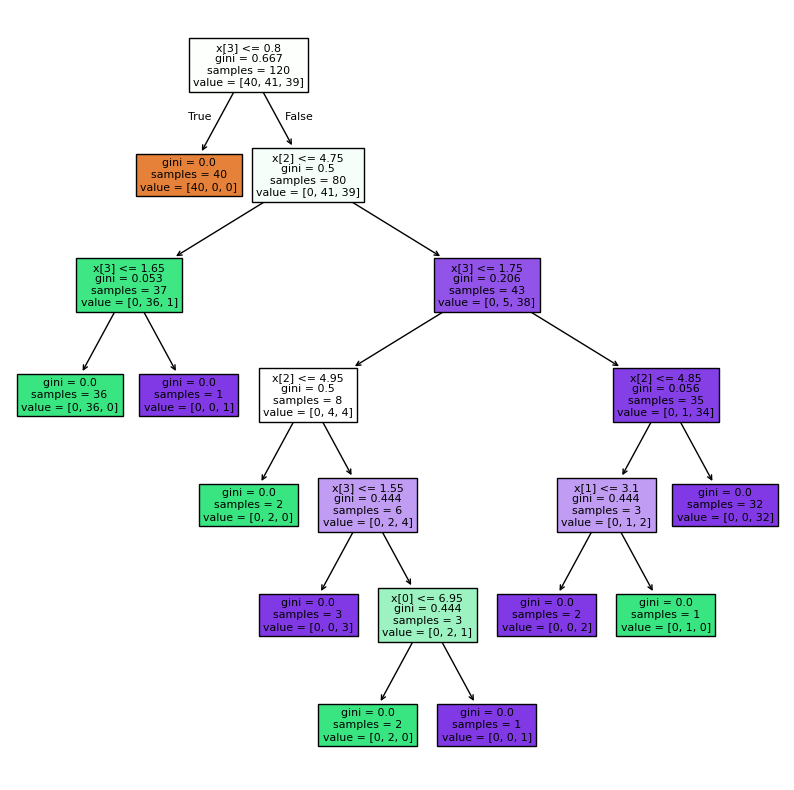

In [11]:
#Visualize the decision tree
# 1. Install the correct packages (if you haven't already)
!pip install scikit-learn matplotlib

# 2. Import the required libraries
import matplotlib.pyplot as plt
from sklearn import tree

# 3. Plot the tree
# (Assuming 'treeclassifier' is your trained DecisionTreeClassifier model)
plt.figure(figsize=(10, 10))
tree.plot_tree(treeclassifier, filled=True)
plt.show()

#X[3]<=0.5 (Max Info Gain)
#Leaf node- gini=0.0(pure split-not split further)
#Impure split - to be split further until we get leaf nodes
#leads to overfitting
#after max_depth=2 , we dont require further splits.

## Reduction of overfitting

#Post Pruning-
Construct entire decision tree first and then pruning it.(usually done with respect to smaller datasets)
#Pre Pruning-
Hyperparameter tuning-
max_depth
coeff-gini/entropy
max_feature
(done wrt larger datasets)


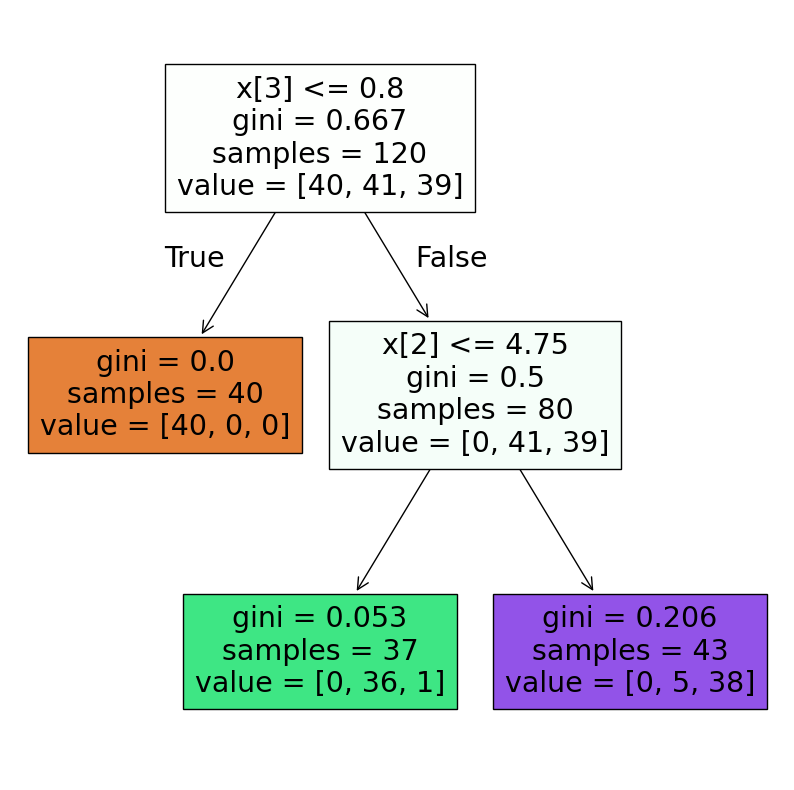

In [12]:
from sklearn.tree import DecisionTreeClassifier
treeclassifier = DecisionTreeClassifier(max_depth=2)
treeclassifier.fit(X_train,y_train)

#Plot the tree
#Assuming 'treeclassifier' is your trained DecisionTreeClassifier model)
plt.figure(figsize=(10, 10))
tree.plot_tree(treeclassifier, filled=True)
plt.show()

In [ ]:
y_pred = treeclassifier.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)

0.9666666666666667

In [ ]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      0.89      0.94         9\n           2       0.92      1.00      0.96        11\n\n    accuracy                           0.97        30\n   macro avg       0.97      0.96      0.97        30\nweighted avg       0.97      0.97      0.97        30\n'

In [ ]:
confusion_matrix(y_test,y_pred)

array([[10,  0,  0],
       [ 0,  8,  1],
       [ 0,  0, 11]])

#Prepruning and Hyperparameter tuning-

Here is the complete list of parameters for `scikit-learn`'s `DecisionTreeClassifier`.

To make them easier to digest, they are broken down by their core function: how they split data, how they stop growing, how they handle imbalanced data, and how they prune.

### 1. The Splitting Rules

These parameters control the underlying math used to decide how the data is divided at each step.

* **`criterion`** *(default="gini")*: The function used to measure the quality of a split.
* Supported criteria are `"gini"` for the Gini impurity and `"log_loss"` or `"entropy"` for the Shannon information gain.


* **`splitter`** *(default="best")*: The strategy used to choose the split at each node.
* `"best"` chooses the absolute best split mathematically.
* `"random"` chooses the best random split, which can introduce variance and speed up training on massive datasets.



### 2. The Stopping Criteria (Pre-pruning)

These are the parameters we discussed earlier that halt the growth of the tree to prevent overfitting.

* **`max_depth`** *(default=None)*: The maximum depth of the tree.
* **`min_samples_split`** *(default=2)*: The minimum number of samples required to split an internal node.
* **`min_samples_leaf`** *(default=1)*: The minimum number of samples required to be at a leaf node.
* **`min_weight_fraction_leaf`** *(default=0.0)*: The minimum weighted fraction of the sum total of weights required to be at a leaf node.
* **`max_features`** *(default=None)*: The number of features to consider when looking for the best split (e.g., `"sqrt"`, `"log2"`, or an exact integer).
* **`max_leaf_nodes`** *(default=None)*: Grow a tree with this maximum number of leaves in best-first fashion.
* **`min_impurity_decrease`** *(default=0.0)*: A node will split if this split induces a decrease of the impurity greater than or equal to this value.

### 3. Class Weights and Randomness

These parameters deal with how the model handles specific dataset quirks and reproducibility.

* **`class_weight`** *(default=None)*: Weights associated with classes (e.g., `{class_label: weight}`). This is incredibly useful for **imbalanced datasets**. If you set it to `"balanced"`, the algorithm automatically adjusts weights inversely proportional to class frequencies (giving minority classes more importance).
* **`random_state`** *(default=None)*: Controls the randomness of the estimator. Even when `splitter` is set to `"best"`, the model needs to randomly shuffle the features at each node if they yield identical improvements. Setting an integer (like `42`) ensures your tree looks exactly the same every time you run the script.

### 4. Post-Pruning

Instead of stopping the tree from growing (pre-pruning), this parameter lets the tree grow massive and then cuts back the weakest branches.

* **`ccp_alpha`** *(default=0.0)*: Complexity parameter used for Minimal Cost-Complexity Pruning. The tree will first be fully grown, and then the algorithm will prune the branches that have the lowest cost-complexity (essentially penalizing branches that add complexity without significantly improving accuracy).

In [15]:
param = {
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7,8,9,10],
    'max_features':['auto','sqrt','log2'],
    'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10],
}

In [16]:
from sklearn.model_selection import GridSearchCV

treemodel = DecisionTreeClassifier()

In [17]:
grid=GridSearchCV(treemodel,param,cv=5,scoring='accuracy')

In [19]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [20]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'log2',
 'min_samples_leaf': 3,
 'splitter': 'random'}

In [ ]:
grid.best_score_

np.float64(0.9666666666666668)

In [ ]:
y_pred = grid.predict(X_test)
print(accuracy_score(y_test,y_pred))
classification_report(y_test,y_pred)
confusion_matrix(y_test,y_pred)

0.9666666666666667


array([[10,  0,  0],
       [ 0,  8,  1],
       [ 0,  0, 11]])

## Diabetes prediction using Decision Tree Regressor-

In Decision Tree Regression, the algorithm does not use Entropy or Gini Impurity (which are classification metrics). Instead, it looks for the split that minimizes the variance of the target variable within the resulting child nodes. This concept is fundamentally tied to the Mean Squared Error (MSE).

Here is the formula for Variance Reduction, which is the exact regression equivalent of Information Gain.

## Variance Reduction Formula

Let $S$ be the current node (dataset), $A$ be the attribute you are splitting on, and $S_v$ be the subset of $S$ created by the split.

$$Variance\ Reduction = Var(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Var(S_v)$$

* $Var(S)$ is the variance of the target variable in the parent node.
* $\frac{|S_v|}{|S|}$ is the weight of the child node (number of samples in the child divided by total samples in the parent).
* $Var(S_v)$ is the variance of the target variable in the child node.

---

## How Variance is Calculated

The variance for any given node $N$ (whether it is the parent or a child) is calculated as the Mean Squared Error from the mean of that node:

$$Var(N) = \frac{1}{|N|} \sum_{i \in N} (y_i - \bar{y})^2$$

* $|N|$ is the number of samples in the node.
* $y_i$ is the actual target value for sample $i$.
* $\bar{y}$ is the mean of the target values in node $N$.

## The Intuition

1. **Calculate Parent Variance:** The tree looks at the target values of all data points in the current node and calculates how spread out they are from their mean.
2. **Test a Split:** It tests a potential split (e.g., `Age > 30`). This creates two child nodes.
3. **Calculate Child Variance:** It calculates the variance within Child A and Child B independently.
4. **Weighted Average:** It calculates the weighted average of the child variances.
5. **Find the Drop:** It subtracts the weighted child variance from the parent variance. The split that produces the largest Variance Reduction (meaning the children are as "pure" or tightly clustered around their respective means as possible) is chosen.


In [21]:
from sklearn.datasets import load_diabetes


## Diabetes Dataset information-
Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times the square root of `n_samples` (i.e. the sum of squares of each column totals 1).


In [22]:
diabetes = load_diabetes()

In [23]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [24]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

df_diabetes = pd.DataFrame(diabetes['data'],columns=diabetes['feature_names'])
print(df_diabetes)

          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -0.002592  0.019907 -0.017646  
1  

In [27]:
#Independent and dependent features-
X=df_diabetes
y=diabetes['target']

In [28]:
#train test split-
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.171161,0.184695,0.314569,0.270283,0.218952,-0.043783,0.180038,0.268422,0.281806
sex,0.171161,1.000000,0.033934,0.179283,0.021069,0.120205,-0.355094,0.320490,0.113187,0.165951
bmi,0.184695,0.033934,1.000000,0.394309,0.266467,0.261560,-0.354655,0.430974,0.468473,0.404928
bp,0.314569,0.179283,0.394309,1.000000,0.239978,0.161457,-0.120827,0.212785,0.375295,0.374647
s1,0.270283,0.021069,0.266467,0.239978,1.000000,0.891063,0.053003,0.546840,0.528543,0.330773
s2,0.218952,0.120205,0.261560,0.161457,0.891063,1.000000,-0.190658,0.654675,0.307139,0.293291
s3,-0.043783,-0.355094,-0.354655,-0.120827,0.053003,-0.190658,1.000000,-0.736685,-0.372437,-0.288236
s4,0.180038,0.320490,0.430974,0.212785,0.546840,0.654675,-0.736685,1.000000,0.613472,0.431352
s5,0.268422,0.113187,0.468473,0.375295,0.528543,0.307139,-0.372437,0.613472,1.000000,0.478967
s6,0.281806,0.165951,0.404928,0.374647,0.330773,0.293291,-0.288236,0.431352,0.478967,1.000000


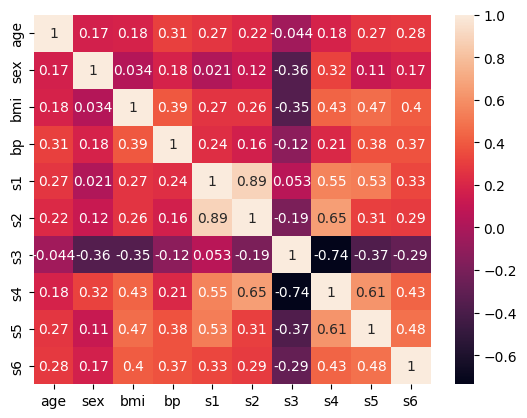

In [30]:
#Check correlation-
import seaborn as sns
sns.heatmap(X_train.corr(),annot=True)
X_train.corr()

In [43]:
#Model
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train,y_train)

DecisionTreeRegressor()

In [44]:
param_grid = {
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt']
}

In [45]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(regressor, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse'],
                         'max_depth': [3, 5, 7, 10, None],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [36]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 5,
 'min_samples_split': 5,
 'splitter': 'random'}

In [37]:
y_pred = grid.predict(X_test)

In [39]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.3011557467802093
3702.582902137213
49.21912060589427


In [48]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the model with your specified hyperparameters
dt_model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    max_features=None,
    min_samples_leaf=5,
    min_samples_split=5,
    splitter='random',
    random_state=42  # Recommended for reproducibility
)

# Example usage:
# dt_model.fit(X_train, y_train)
# predictions = dt_model.predict(X_test)

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

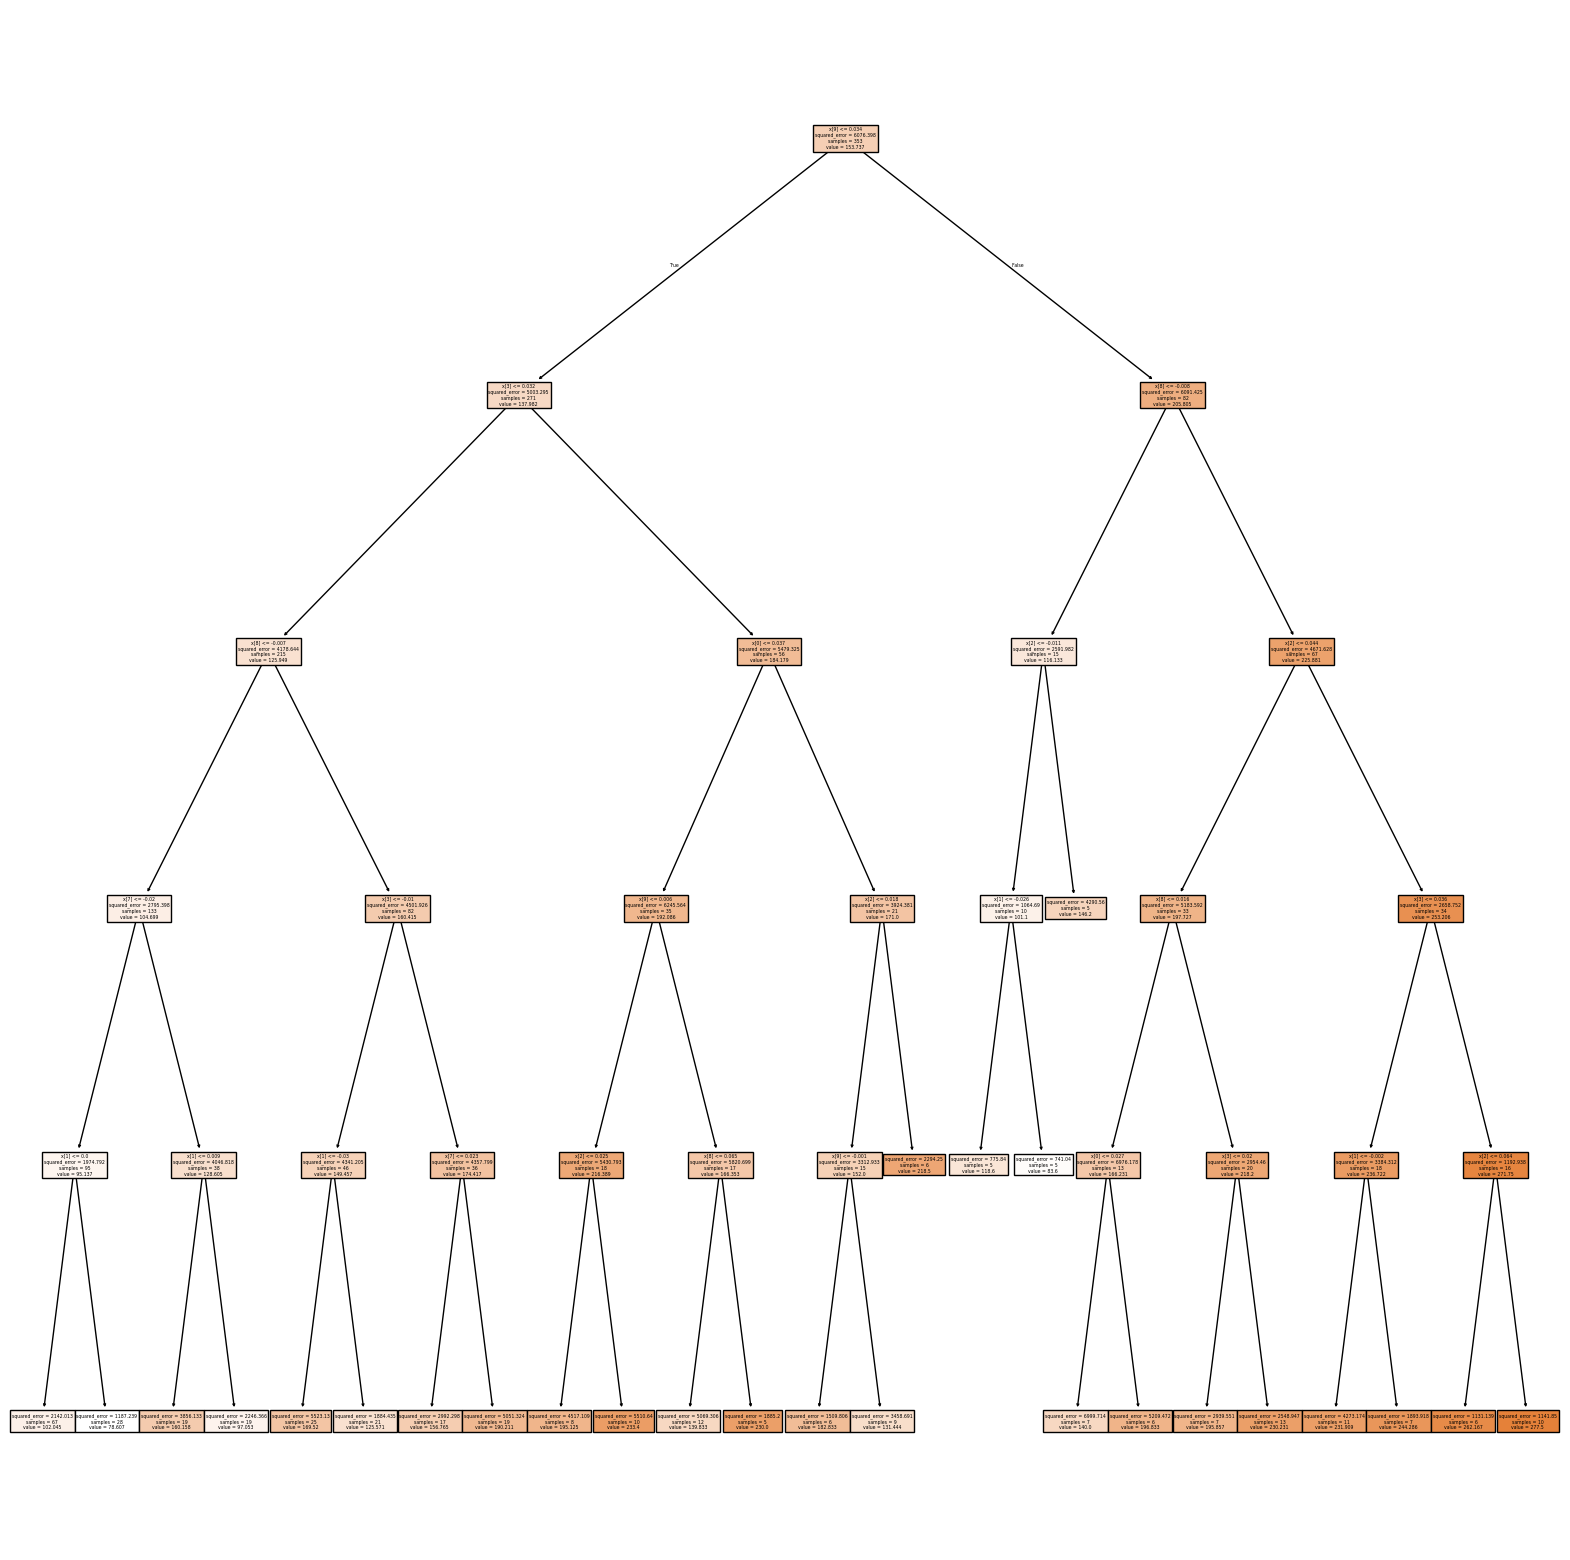

In [51]:
#VISUalize the decision tree Regressor-

import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20, 20))
tree.plot_tree(dt_model, filled=True)
plt.show()